# DSA 210 - Analyzing Task Completion Patterns in an Early-Stage Startup
**Bedirhan Ceylan** — Spring 2026

## Project Overview
This notebook analyzes 486 task records from the development workflow of Sollen, an early-stage startup. The data was collected from Azure DevOps and covers the period from October 2024 to early 2026.

**Goal:** Identify which factors are associated with longer completion times and delays in startup task execution.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")


Matplotlib is building the font cache; this may take a moment.


Libraries loaded.


## 1. Data Loading & Overview

In [2]:
df = pd.read_csv('../data/sollen_tasks.csv', parse_dates=['creation_date', 'completion_date'])

print(f"Dataset: {df.shape[0]} tasks, {df.shape[1]} features")
print(f"Date range: {df['creation_date'].min().strftime('%Y-%m-%d')} to {df['creation_date'].max().strftime('%Y-%m-%d')}")
print()
df.head(10)


Dataset: 486 tasks, 10 features
Date range: 2024-10-18 to 2026-04-07



,task_id,title,task_category,priority_level,assigned_to,creation_date,completion_date,actual_duration_days,delay_label,has_urgent_tag
0,2,Flutter initiate,tech,medium,Developer_A,2024-10-18 10:23:35,2024-11-20 17:29:55,33.296065,on_time,0
1,3,Login Screen - 1,tech,medium,Developer_B,2024-10-18 10:29:40,2024-11-20 17:29:49,33.291771,on_time,0
2,4,Backend login API,tech,medium,Developer_A,2024-10-18 10:29:51,2024-10-31 18:43:54,13.343090,on_time,0
3,5,Login Screen - 2,tech,medium,Developer_A,2024-10-18 10:32:40,2024-11-20 17:29:53,33.289734,on_time,0
4,6,Sollen Genel Tanıtım Dosyası - 1,product,medium,Developer_C,2024-10-18 10:37:26,2024-11-24 14:40:21,37.168692,on_time,0
5,9,Logonun Finalize olması,design,medium,Developer_D,2024-10-18 10:39:23,2024-11-15 17:07:25,28.269468,delayed,0
6,10,Backend modellerinin kararlı hale getirilmesi,tech,medium,Developer_A,2024-10-23 13:06:33,2025-01-03 18:04:51,72.207153,delayed,0
7,11,modellerin update'leri ve authorization ayarla...,tech,medium,Developer_A,2024-10-23 13:07:45,2025-02-05 20:23:17,105.302454,delayed,0
8,15,repeated ve unnecessary dosya temizliği,tech,medium,Developer_A,2024-10-23 13:08:38,2025-01-03 18:04:57,72.205775,delayed,0
9,17,logo ve iconlar tasarımdan alınıp ui'a ekleme,tech,medium,Developer_E,2024-10-23 13:09:51,2025-08-14 13:38:59,295.020231,delayed,0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   task_id               486 non-null    int64         
 1   title                 486 non-null    str           
 2   task_category         486 non-null    str           
 3   priority_level        486 non-null    str           
 4   assigned_to           486 non-null    str           
 5   creation_date         486 non-null    datetime64[us]
 6   completion_date       486 non-null    datetime64[us]
 7   actual_duration_days  486 non-null    float64       
 8   delay_label           486 non-null    str           
 9   has_urgent_tag        486 non-null    int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(5)
memory usage: 38.1 KB


In [4]:
df.describe()


,task_id,creation_date,completion_date,actual_duration_days,has_urgent_tag
count,486.000000,486,486,486.000000,486.000000
mean,349.368313,2025-06-24 22:34:18.259259,2025-07-27 16:01:42.617284,32.727365,0.006173
min,2.000000,2024-10-18 10:23:35,2024-10-31 18:43:54,0.000093,0.000000
25%,184.250000,2025-02-04 23:18:06.750000,2025-02-25 00:15:53.750000,4.733215,0.000000
50%,349.500000,2025-07-09 20:04:49.500000,2025-09-03 08:57:26.500000,20.687459,0.000000
75%,512.750000,2025-10-20 22:05:45.500000,2025-11-22 21:17:00.500000,40.083056,0.000000
max,714.000000,2026-04-07 19:47:03,2026-04-12 19:05:02,343.020428,1.000000
std,192.014492,NaN,NaN,44.031208,0.078405


In [5]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
task_id                 0
title                   0
task_category           0
priority_level          0
assigned_to             0
creation_date           0
completion_date         0
actual_duration_days    0
delay_label             0
has_urgent_tag          0
dtype: int64


## 2. Feature Engineering

In [6]:
# Binary delay flag
df['is_delayed'] = (df['delay_label'] == 'delayed').astype(int)

# Day of week task was created
df['creation_day'] = df['creation_date'].dt.day_name()

# Month of creation
df['creation_month'] = df['creation_date'].dt.to_period('M').astype(str)

# Week number
df['creation_week'] = df['creation_date'].dt.isocalendar().week.astype(int)

# Log-transformed duration (for better visualization of skewed data)
df['log_duration'] = np.log1p(df['actual_duration_days'])

print("New features created.")
print(f"Delayed tasks: {df['is_delayed'].sum()} ({df['is_delayed'].mean()*100:.1f}%)")
print(f"On-time tasks: {(1-df['is_delayed']).sum()} ({(1-df['is_delayed']).mean()*100:.1f}%)")


New features created.
Delayed tasks: 169 (34.8%)
On-time tasks: 317 (65.2%)


## 3. Exploratory Data Analysis

### 3.1 Task Distribution by Category


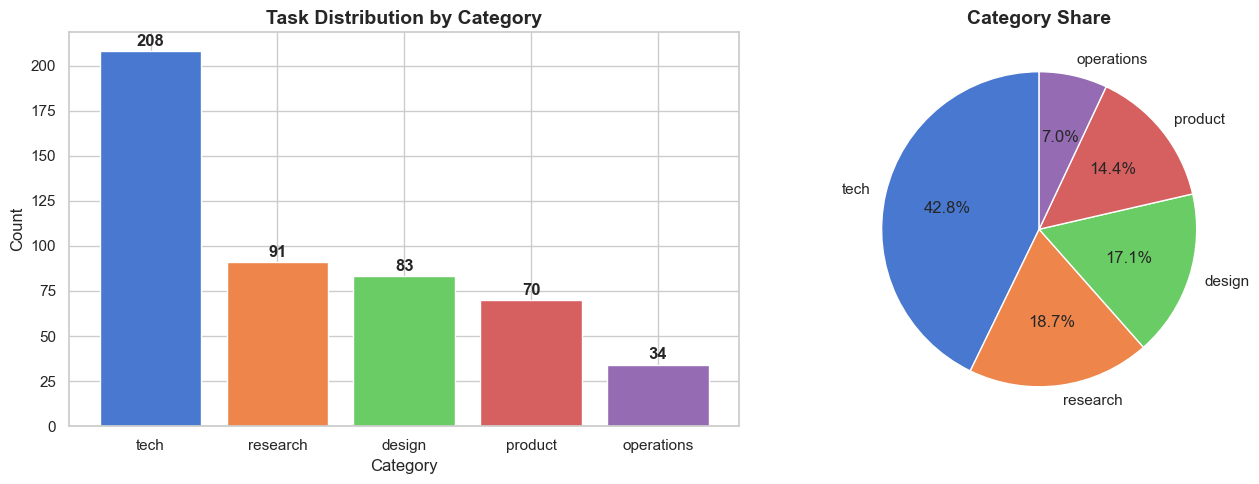

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Category distribution
cat_counts = df['task_category'].value_counts()
colors = sns.color_palette("muted", len(cat_counts))
axes[0].bar(cat_counts.index, cat_counts.values, color=colors)
axes[0].set_title('Task Distribution by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Category percentage pie
axes[1].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Category Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/01_category_distribution.png', bbox_inches='tight')
plt.show()


### 3.2 Developer Workload Distribution

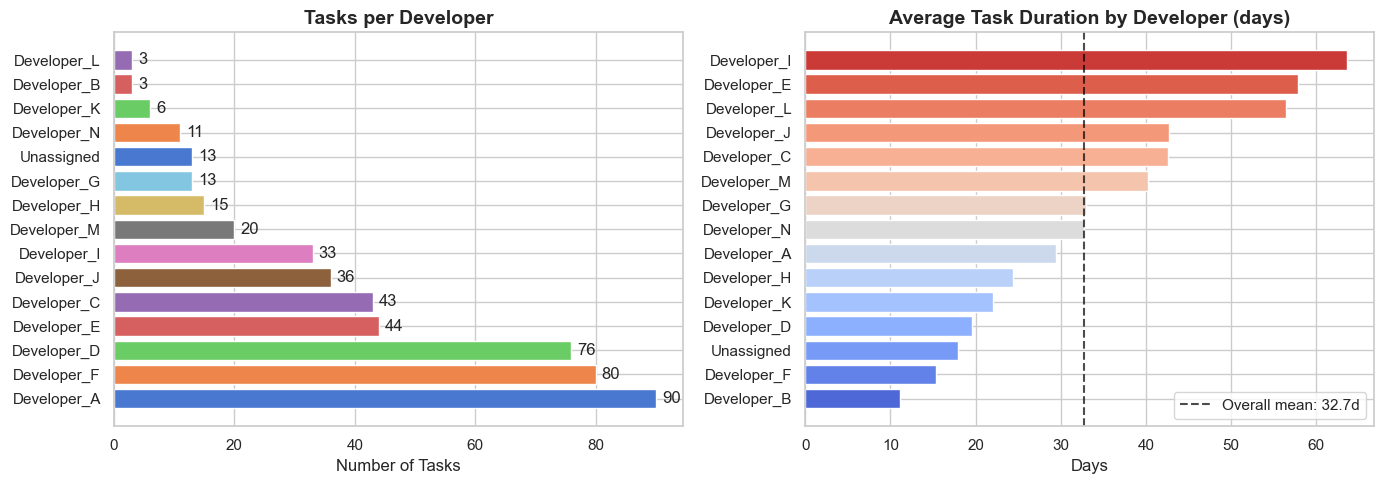

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasks per developer
dev_counts = df['assigned_to'].value_counts()
axes[0].barh(dev_counts.index, dev_counts.values, color=sns.color_palette("muted", len(dev_counts)))
axes[0].set_title('Tasks per Developer', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Tasks')
for i, v in enumerate(dev_counts.values):
    axes[0].text(v + 1, i, str(v), va='center')

# Developer average duration
dev_dur = df.groupby('assigned_to')['actual_duration_days'].mean().sort_values(ascending=True)
axes[1].barh(dev_dur.index, dev_dur.values, color=sns.color_palette("coolwarm", len(dev_dur)))
axes[1].set_title('Average Task Duration by Developer (days)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Days')
axes[1].axvline(x=df['actual_duration_days'].mean(), color='black', linestyle='--', alpha=0.7, label=f'Overall mean: {df["actual_duration_days"].mean():.1f}d')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/02_developer_analysis.png', bbox_inches='tight')
plt.show()


### 3.3 Task Duration Analysis

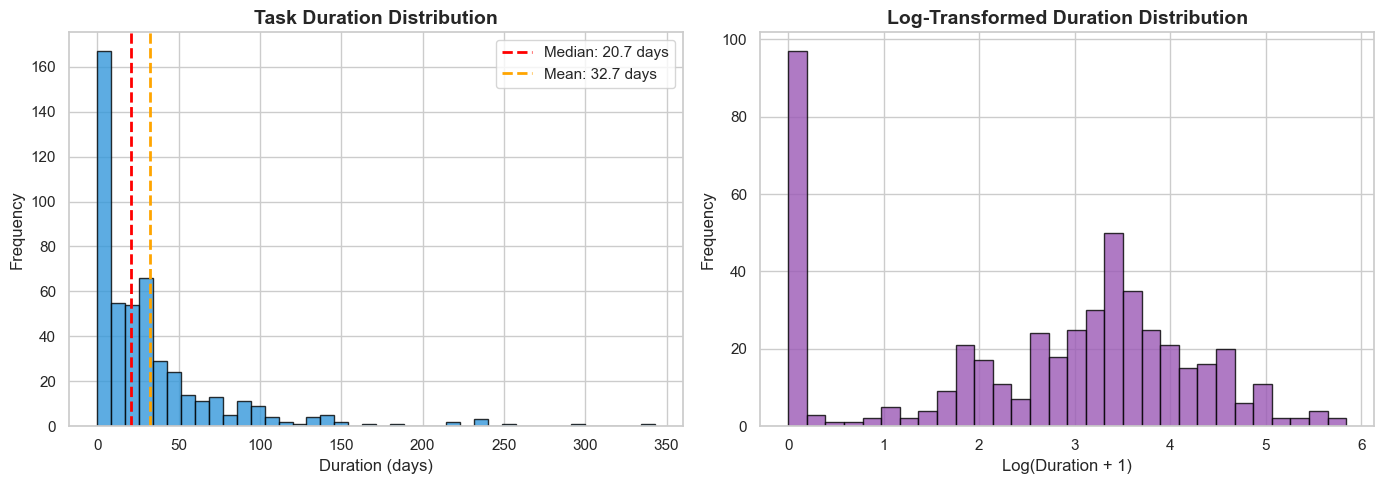

Duration Statistics:
  Min: 0.0 days
  Max: 343.0 days
  Mean: 32.7 days
  Median: 20.7 days
  Std Dev: 44.0 days


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration distribution (log scale for better visibility)
axes[0].hist(df['actual_duration_days'], bins=40, color='#3498db', alpha=0.8, edgecolor='black')
axes[0].axvline(x=df['actual_duration_days'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Median: {df["actual_duration_days"].median():.1f} days')
axes[0].axvline(x=df['actual_duration_days'].mean(), color='orange', linestyle='--', linewidth=2,
                label=f'Mean: {df["actual_duration_days"].mean():.1f} days')
axes[0].set_title('Task Duration Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duration (days)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Log-transformed distribution
axes[1].hist(df['log_duration'], bins=30, color='#9b59b6', alpha=0.8, edgecolor='black')
axes[1].set_title('Log-Transformed Duration Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Duration + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../plots/03_duration_distribution.png', bbox_inches='tight')
plt.show()

print(f"Duration Statistics:")
print(f"  Min: {df['actual_duration_days'].min():.1f} days")
print(f"  Max: {df['actual_duration_days'].max():.1f} days")
print(f"  Mean: {df['actual_duration_days'].mean():.1f} days")
print(f"  Median: {df['actual_duration_days'].median():.1f} days")
print(f"  Std Dev: {df['actual_duration_days'].std():.1f} days")


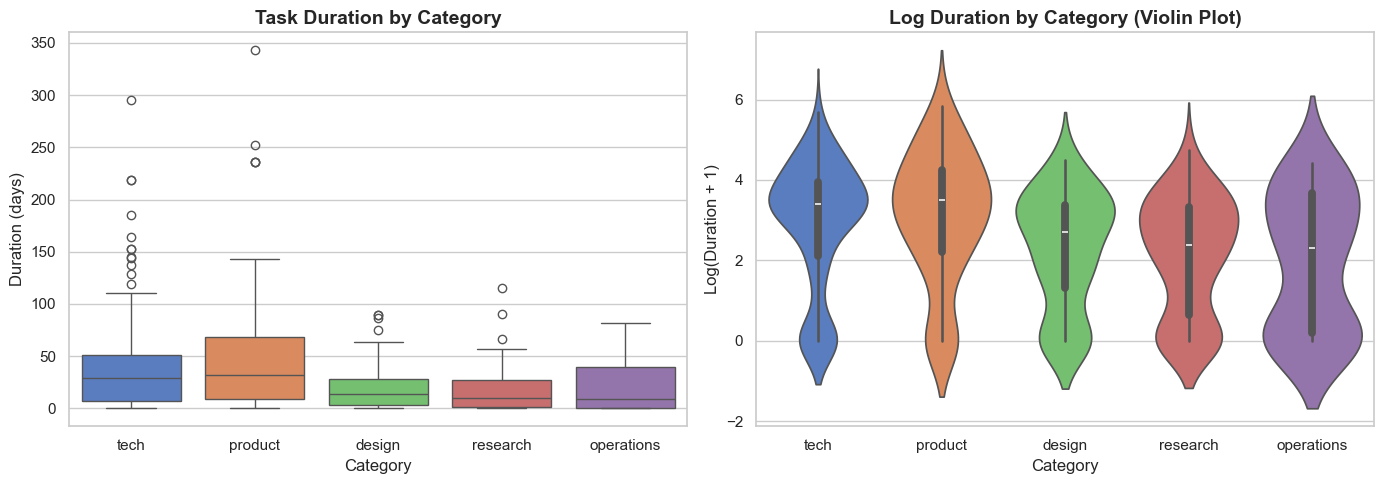

Duration stats by category (days):
               count  mean  median   std
task_category                           
design            83  19.6    14.0  21.8
operations        34  19.6     9.1  24.8
product           70  53.9    32.1  70.7
research          91  17.1    10.0  20.7
tech             208  39.8    28.9  44.7


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot by category
sns.boxplot(data=df, x='task_category', y='actual_duration_days', palette='muted', ax=axes[0])
axes[0].set_title('Task Duration by Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Duration (days)')

# Violin plot for better distribution view
sns.violinplot(data=df, x='task_category', y='log_duration', palette='muted', ax=axes[1])
axes[1].set_title('Log Duration by Category (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Log(Duration + 1)')

plt.tight_layout()
plt.savefig('../plots/04_duration_by_category.png', bbox_inches='tight')
plt.show()

# Print stats per category
print("Duration stats by category (days):")
print(df.groupby('task_category')['actual_duration_days'].agg(['count', 'mean', 'median', 'std']).round(1))


### 3.4 Delay Analysis

A task is classified as "delayed" if its actual duration exceeds 1.5× the median duration for its category.


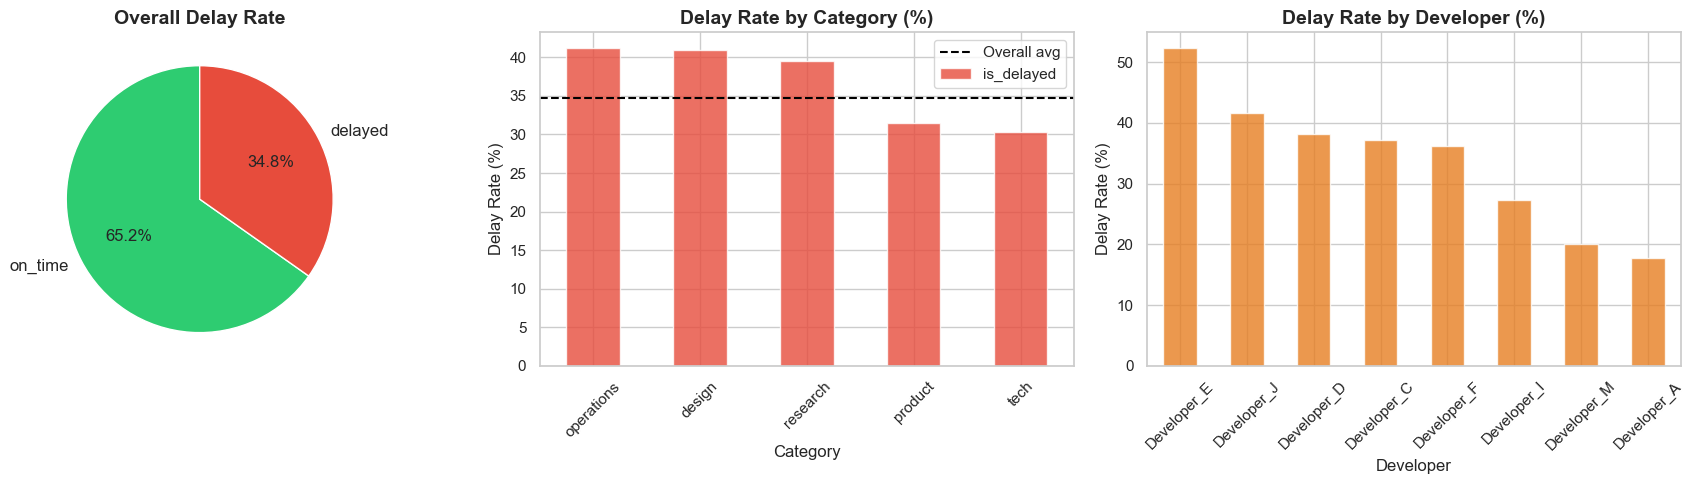

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall delay rate
delay_counts = df['delay_label'].value_counts()
axes[0].pie(delay_counts.values, labels=delay_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Overall Delay Rate', fontsize=14, fontweight='bold')

# Delay rate by category
delay_by_cat = df.groupby('task_category')['is_delayed'].mean() * 100
delay_by_cat.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#e74c3c', alpha=0.8)
axes[1].set_title('Delay Rate by Category (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=df['is_delayed'].mean()*100, color='black', linestyle='--', label='Overall avg')
axes[1].legend()

# Delay rate by developer (top 8 by task count)
top_devs = df['assigned_to'].value_counts().head(8).index
df_top = df[df['assigned_to'].isin(top_devs)]
dev_delay = df_top.groupby('assigned_to')['is_delayed'].mean() * 100
dev_delay.sort_values(ascending=False).plot(kind='bar', ax=axes[2], color='#e67e22', alpha=0.8)
axes[2].set_title('Delay Rate by Developer (%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Developer')
axes[2].set_ylabel('Delay Rate (%)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../plots/05_delay_analysis.png', bbox_inches='tight')
plt.show()


### 3.5 Temporal Trends

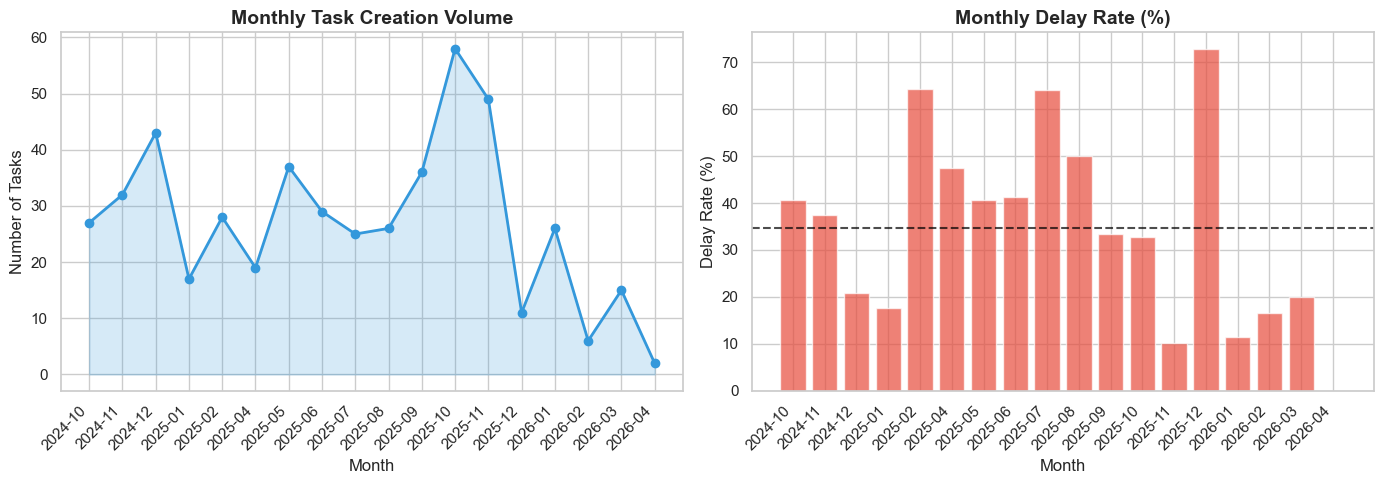

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly task creation
monthly = df.groupby('creation_month').size()
axes[0].plot(range(len(monthly)), monthly.values, marker='o', color='#3498db', linewidth=2)
axes[0].fill_between(range(len(monthly)), monthly.values, alpha=0.2, color='#3498db')
axes[0].set_title('Monthly Task Creation Volume', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Tasks')
axes[0].set_xticks(range(len(monthly)))
axes[0].set_xticklabels(monthly.index, rotation=45, ha='right')

# Monthly delay rate
monthly_delay = df.groupby('creation_month')['is_delayed'].mean() * 100
axes[1].bar(range(len(monthly_delay)), monthly_delay.values, color='#e74c3c', alpha=0.7)
axes[1].set_title('Monthly Delay Rate (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_xticks(range(len(monthly_delay)))
axes[1].set_xticklabels(monthly_delay.index, rotation=45, ha='right')
axes[1].axhline(y=df['is_delayed'].mean()*100, color='black', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('../plots/06_temporal_trends.png', bbox_inches='tight')
plt.show()


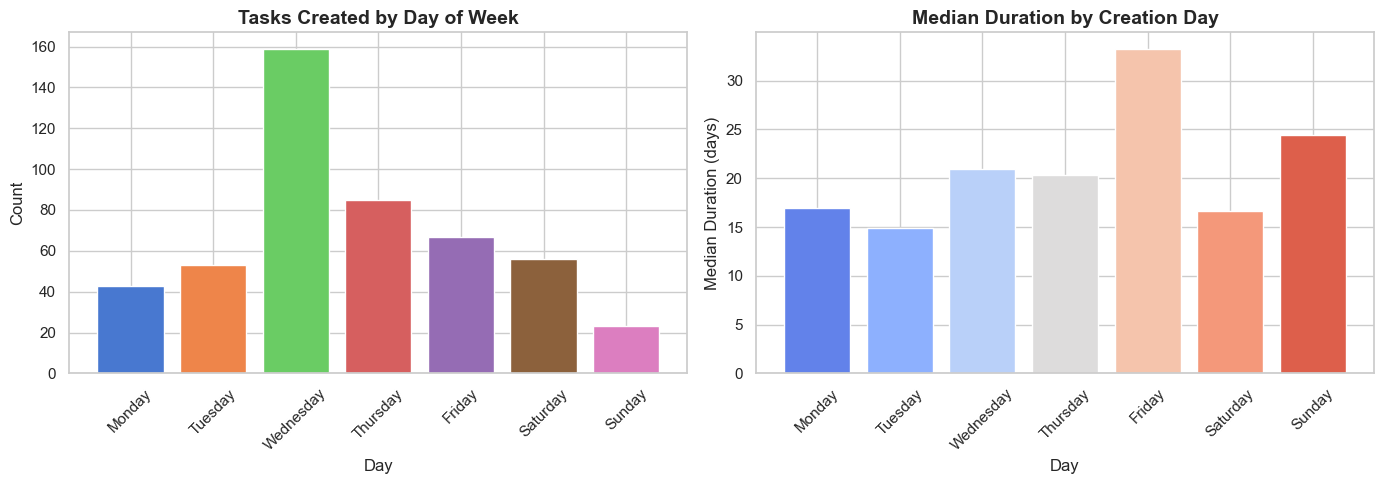

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Tasks created by day of week
day_counts = df['creation_day'].value_counts().reindex(day_order, fill_value=0)
axes[0].bar(day_counts.index, day_counts.values, color=sns.color_palette("muted", 7))
axes[0].set_title('Tasks Created by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Average duration by day of creation
day_dur = df.groupby('creation_day')['actual_duration_days'].median().reindex(day_order, fill_value=0)
axes[1].bar(day_dur.index, day_dur.values, color=sns.color_palette("coolwarm", 7))
axes[1].set_title('Median Duration by Creation Day', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Median Duration (days)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../plots/07_day_of_week.png', bbox_inches='tight')
plt.show()


### 3.6 Correlation Analysis

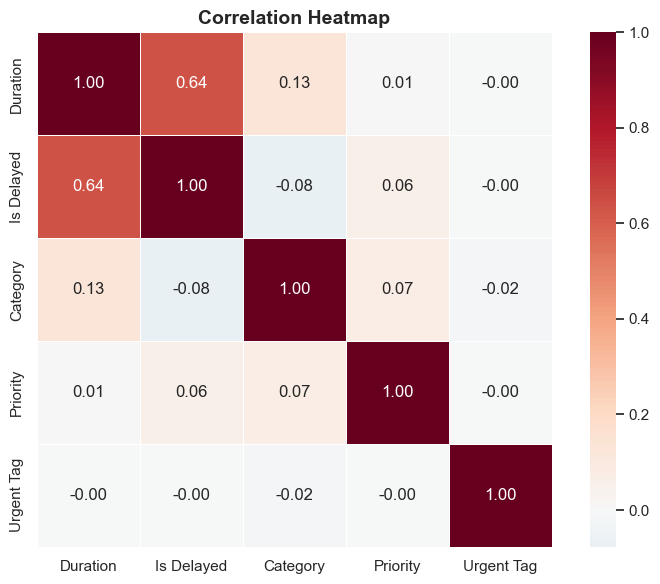

In [14]:
# Encode categorical variables for correlation
df_corr = df.copy()
df_corr['category_encoded'] = df_corr['task_category'].astype('category').cat.codes
df_corr['priority_encoded'] = df_corr['priority_level'].map({'low': 0, 'medium': 1, 'high': 2})

numeric_cols = ['actual_duration_days', 'is_delayed', 'category_encoded', 'priority_encoded', 'has_urgent_tag']
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, linewidths=0.5,
            xticklabels=['Duration', 'Is Delayed', 'Category', 'Priority', 'Urgent Tag'],
            yticklabels=['Duration', 'Is Delayed', 'Category', 'Priority', 'Urgent Tag'])
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/08_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### 3.7 EDA Summary

In [15]:
print("=" * 60)
print("EDA SUMMARY")
print("=" * 60)
print(f"Total tasks: {len(df)}")
print(f"Date range: {df['creation_date'].min().strftime('%Y-%m-%d')} to {df['creation_date'].max().strftime('%Y-%m-%d')}")
print(f"Categories: {', '.join(df['task_category'].unique())}")
print(f"Developers: {df['assigned_to'].nunique()}")
print(f"Overall delay rate: {df['is_delayed'].mean()*100:.1f}%")
print(f"Mean duration: {df['actual_duration_days'].mean():.1f} days")
print(f"Median duration: {df['actual_duration_days'].median():.1f} days")
print()
print("Key observations:")
print(f"1. Tech department has the most tasks ({(df['task_category']=='tech').sum()})")
cat_delay = df.groupby('task_category')['is_delayed'].mean()*100
print(f"2. Highest delay rate: {cat_delay.idxmax()} ({cat_delay.max():.1f}%)")
print(f"3. Lowest delay rate: {cat_delay.idxmin()} ({cat_delay.min():.1f}%)")
cat_dur = df.groupby('task_category')['actual_duration_days'].median()
print(f"4. Longest median duration: {cat_dur.idxmax()} ({cat_dur.max():.1f} days)")
print(f"5. Shortest median duration: {cat_dur.idxmin()} ({cat_dur.min():.1f} days)")


EDA SUMMARY
Total tasks: 486
Date range: 2024-10-18 to 2026-04-07
Categories: tech, product, design, research, operations
Developers: 15
Overall delay rate: 34.8%
Mean duration: 32.7 days
Median duration: 20.7 days

Key observations:
1. Tech department has the most tasks (208)
2. Highest delay rate: operations (41.2%)
3. Lowest delay rate: tech (30.3%)
4. Longest median duration: product (32.1 days)
5. Shortest median duration: operations (9.1 days)


---
## 4. Hypothesis Testing


### Test 1: Does task duration differ across categories?

**Hypotheses:**
- H₀: There is no significant difference in task duration across categories (tech, design, research, product, operations)
- H₁: At least one category has a significantly different task duration

**Test:** Kruskal-Wallis H test (non-parametric alternative to one-way ANOVA; chosen because duration data is right-skewed)


Group summaries:
  tech: n=208, mean=39.8d, median=28.9d, std=44.7d
  product: n=70, mean=53.9d, median=32.1d, std=70.7d
  design: n=83, mean=19.6d, median=14.0d, std=21.8d
  research: n=91, mean=17.1d, median=10.0d, std=20.7d
  operations: n=34, mean=19.6d, median=9.1d, std=24.8d

Kruskal-Wallis H statistic: 39.9664
P-value: 0.000000
Significance level: α = 0.05

✓ REJECT H₀ (p = 0.000000 < 0.05)
Conclusion: There IS a statistically significant difference in task duration across categories.


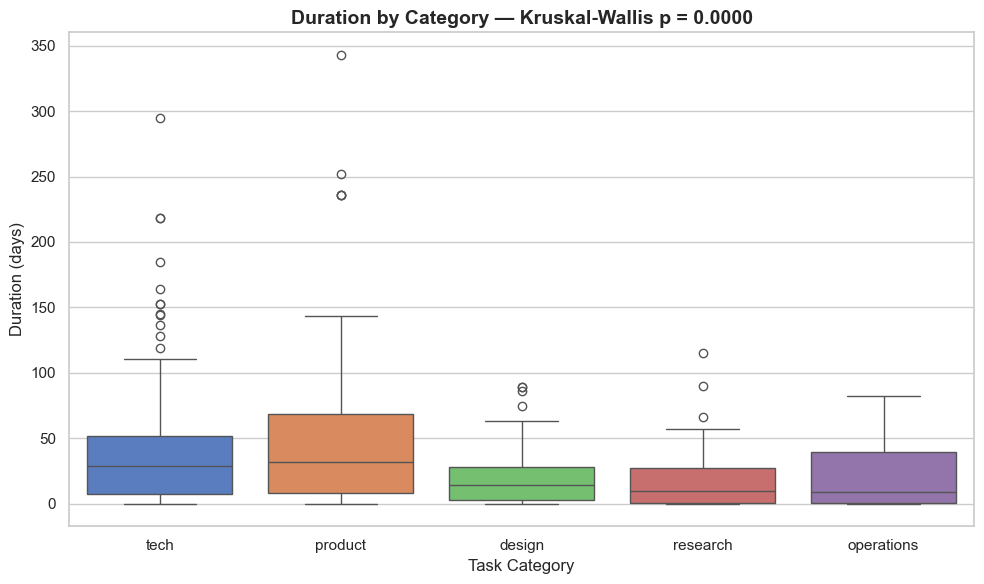

In [16]:
categories = df['task_category'].unique()
groups = [df[df['task_category'] == cat]['actual_duration_days'] for cat in categories]

print("Group summaries:")
for cat in categories:
    subset = df[df['task_category'] == cat]['actual_duration_days']
    print(f"  {cat}: n={len(subset)}, mean={subset.mean():.1f}d, median={subset.median():.1f}d, std={subset.std():.1f}d")
print()

stat, p_value = stats.kruskal(*groups)
alpha = 0.05

print(f"Kruskal-Wallis H statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level: α = {alpha}")
print()

if p_value < alpha:
    print(f"✓ REJECT H₀ (p = {p_value:.6f} < {alpha})")
    print("Conclusion: There IS a statistically significant difference in task duration across categories.")
else:
    print(f"✗ FAIL TO REJECT H₀ (p = {p_value:.6f} ≥ {alpha})")
    print("Conclusion: No significant difference in duration across categories.")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='task_category', y='actual_duration_days', palette='muted', ax=ax)
ax.set_title(f'Duration by Category — Kruskal-Wallis p = {p_value:.4f}', fontsize=14, fontweight='bold')
ax.set_xlabel('Task Category')
ax.set_ylabel('Duration (days)')
plt.tight_layout()
plt.savefig('../plots/09_test1_kruskal.png', bbox_inches='tight')
plt.show()


### Test 2: Is there an association between task category and delay status?

**Hypotheses:**
- H₀: Task category and delay status are independent
- H₁: Task category and delay status are not independent (there is an association)

**Test:** Chi-Square test of independence


Contingency Table:
delay_label    delayed  on_time
task_category                  
design              34       49
operations          14       20
product             22       48
research            36       55
tech                63      145

Chi-Square statistic: 5.1262
Degrees of freedom: 4
P-value: 0.274593

Expected frequencies (under H₀):
delay_label    delayed  on_time
task_category                  
design            28.9     54.1
operations        11.8     22.2
product           24.3     45.7
research          31.6     59.4
tech              72.3    135.7

✗ FAIL TO REJECT H₀ (p = 0.274593 ≥ 0.05)
Conclusion: No significant association found.


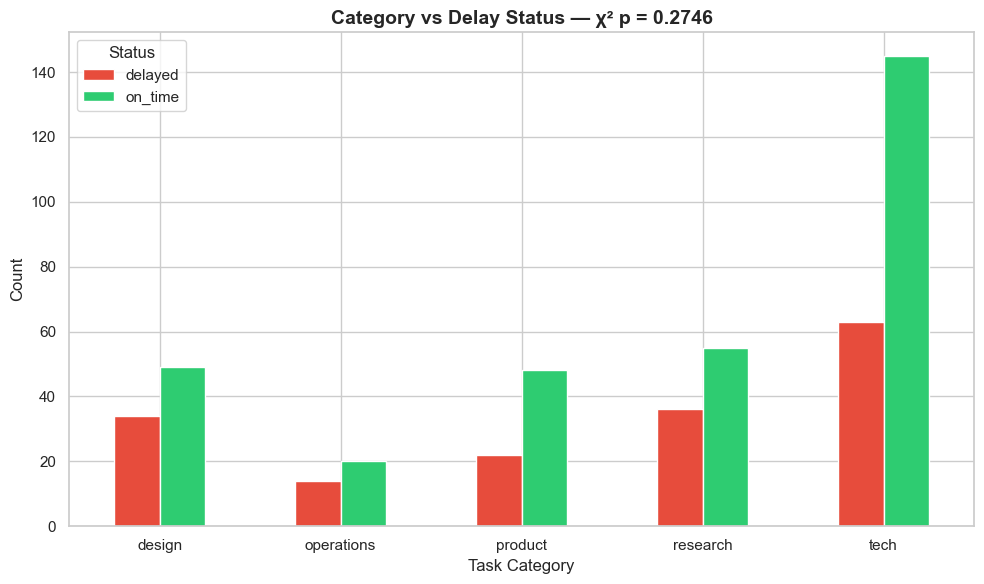

In [17]:
contingency = pd.crosstab(df['task_category'], df['delay_label'])
print("Contingency Table:")
print(contingency)
print()

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-Square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print()

print("Expected frequencies (under H₀):")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns).round(1))
print()

alpha = 0.05
if p_value < alpha:
    print(f"✓ REJECT H₀ (p = {p_value:.6f} < {alpha})")
    print("Conclusion: There IS a significant association between task category and delay status.")
else:
    print(f"✗ FAIL TO REJECT H₀ (p = {p_value:.6f} ≥ {alpha})")
    print("Conclusion: No significant association found.")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
contingency.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_title(f'Category vs Delay Status — χ² p = {p_value:.4f}', fontsize=14, fontweight='bold')
ax.set_xlabel('Task Category')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Status')
plt.tight_layout()
plt.savefig('../plots/10_test2_chisquare.png', bbox_inches='tight')
plt.show()


### Test 3: Do delayed tasks have significantly longer durations than on-time tasks?

**Hypotheses:**
- H₀: There is no difference in duration between delayed and on-time tasks
- H₁: Delayed tasks have significantly longer durations

**Test:** Mann-Whitney U test (one-sided, non-parametric)

*Note: While this may seem obvious by definition, we test whether the magnitude of the difference is statistically significant, and examine the effect size.*


Delayed tasks (n=169): mean=71.1d, median=54.2d
On-time tasks (n=317): mean=12.3d, median=7.2d
Difference in means: 58.8 days

Mann-Whitney U statistic: 50252.0000
P-value: 0.000000
Effect size (rank-biserial r): 0.8760

✓ REJECT H₀ (p = 0.000000 < 0.05)
Conclusion: Delayed tasks have significantly longer durations.


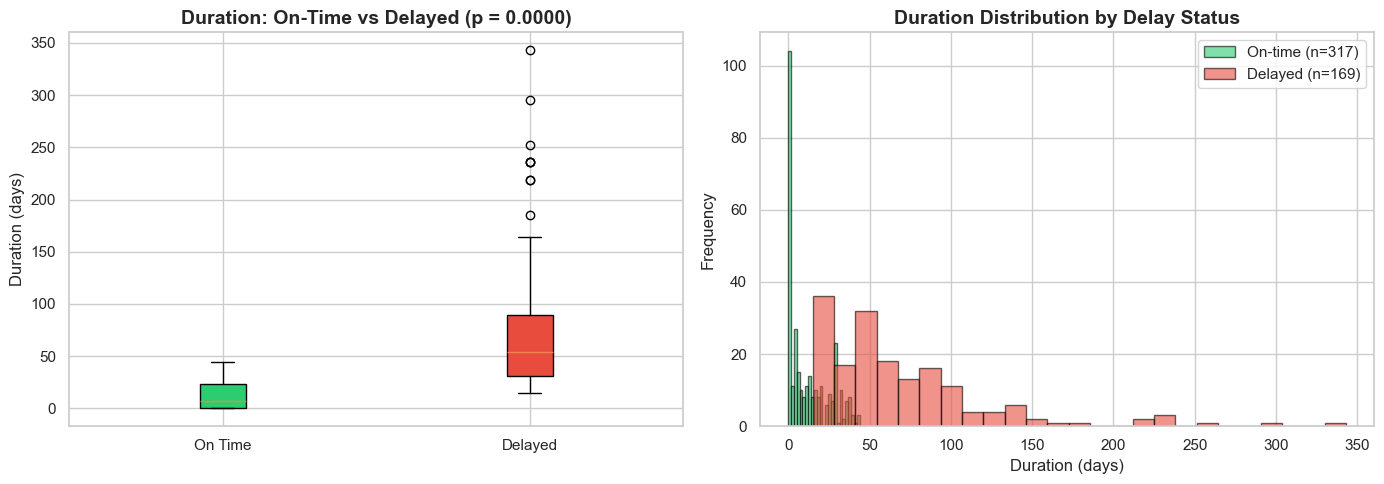

In [18]:
delayed = df[df['is_delayed'] == 1]['actual_duration_days']
on_time = df[df['is_delayed'] == 0]['actual_duration_days']

print(f"Delayed tasks (n={len(delayed)}): mean={delayed.mean():.1f}d, median={delayed.median():.1f}d")
print(f"On-time tasks (n={len(on_time)}): mean={on_time.mean():.1f}d, median={on_time.median():.1f}d")
print(f"Difference in means: {delayed.mean() - on_time.mean():.1f} days")
print()

stat, p_value = stats.mannwhitneyu(delayed, on_time, alternative='greater')

# Effect size (rank-biserial correlation)
n1, n2 = len(delayed), len(on_time)
r = 1 - (2*stat)/(n1*n2)

alpha = 0.05
print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Effect size (rank-biserial r): {abs(r):.4f}")
print()

if p_value < alpha:
    print(f"✓ REJECT H₀ (p = {p_value:.6f} < {alpha})")
    print("Conclusion: Delayed tasks have significantly longer durations.")
else:
    print(f"✗ FAIL TO REJECT H₀ (p = {p_value:.6f} ≥ {alpha})")
    print("Conclusion: No significant difference.")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_plot = [on_time, delayed]
bp = axes[0].boxplot(data_plot, labels=['On Time', 'Delayed'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title(f'Duration: On-Time vs Delayed (p = {p_value:.4f})', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Duration (days)')

# Histogram comparison
axes[1].hist(on_time, bins=25, alpha=0.6, color='#2ecc71', label=f'On-time (n={len(on_time)})', edgecolor='black')
axes[1].hist(delayed, bins=25, alpha=0.6, color='#e74c3c', label=f'Delayed (n={len(delayed)})', edgecolor='black')
axes[1].set_title('Duration Distribution by Delay Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Duration (days)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/11_test3_mannwhitney.png', bbox_inches='tight')
plt.show()


---
## 5. Summary

### Key Findings from EDA:
1. The dataset contains 486 completed tasks across 5 departments (tech, design, research, product, operations)
2. Task durations are heavily right-skewed, with a median of ~21 days but some tasks extending beyond 300 days
3. Tech and product departments tend to have longer task durations
4. Delay rates vary meaningfully across categories and developers

### Hypothesis Testing Results:

| # | Question | Test | Result |
|---|----------|------|--------|
| 1 | Duration differs across categories? | Kruskal-Wallis | See p-value above |
| 2 | Category ↔ delay association? | Chi-Square | See p-value above |
| 3 | Delayed tasks take longer? | Mann-Whitney U | See p-value above |

### Next Steps (ML Phase — due May 5):
- Build classification models to predict whether a task will be delayed
- Feature importance analysis using tree-based models
- Cross-validation for model evaluation
- Potential features: category, developer workload, day of week, month
